### =============================================================================

### MACHINE LEARNING - GRADIENT BOOSTING (XGBoost / LightGBM)

### Predicción de Default en Tarjetas de Crédito

### Dataset: UCI "Default of Credit Card Clients"

### =============================================================================

In [1]:
# -----------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

# Modelos de Boosting
import xgboost as xgb
import lightgbm as lgb
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [4]:
# -----------------------------------------------------------------------------
# 2. CARGA DEL DATASET
# -----------------------------------------------------------------------------

# El dataset está en formato Excel (.xls)
# Puedes descargarlo desde: https://archive.ics.uci.edu/dataset/350
# Nota: Puede ser necesario instalar 'openpyxl' o 'xlrd'

# Opción 1: Si el archivo está en el mismo directorio
# df = pd.read_excel('default_of_credit_card_clients.xls', header=1)

# Opción 2: Descarga directa desde UCI (requiere internet)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'
df = pd.read_excel(url, header=1)

print(f"📊 Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

📊 Dataset cargado: 30000 filas, 25 columnas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
# -----------------------------------------------------------------------------
# 3. EXPLORACIÓN INICIAL DE DATOS
# -----------------------------------------------------------------------------
print("INFORMACIÓN GENERAL DEL DATASET")
df.info()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-nu

In [6]:
print("ESTADÍSTICAS DESCRIPTIVAS")
df.describe()

ESTADÍSTICAS DESCRIPTIVAS


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
print("VALORES NULOS POR COLUMNA")
print(df.isnull().sum())

VALORES NULOS POR COLUMNA
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


In [8]:
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")

# La última columna es 'default payment next month' (variable objetivo)
# Según la documentación: 1 = Default, 0 = No Default[reference:4]

target_col = df.columns[-1]
print(f"Variable objetivo: '{target_col}'")
print(df[target_col].value_counts())
print(f"\nProporción de defaults: {df[target_col].mean():.2%}")

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
Variable objetivo: 'default payment next month'
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Proporción de defaults: 22.12%


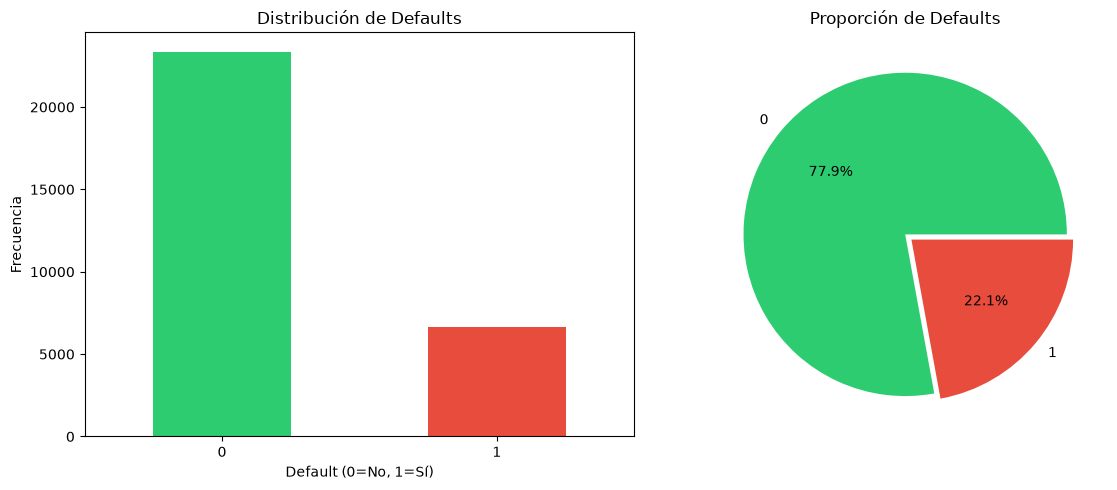

In [9]:
# -----------------------------------------------------------------------------
# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# -----------------------------------------------------------------------------
# 4.1 Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Defaults')
axes[0].set_xlabel('Default (0=No, 1=Sí)')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Porcentaje
df[target_col].value_counts(normalize=True).plot(kind='pie', ax=axes[1], 
                                                   autopct='%1.1f%%', 
                                                   colors=['#2ecc71', '#e74c3c'],
                                                   explode=[0, 0.05])
axes[1].set_title('Proporción de Defaults')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribucion_default.png', dpi=150)
plt.show()

# El dataset está desbalanceado: 77.9% no default, 22.1% default

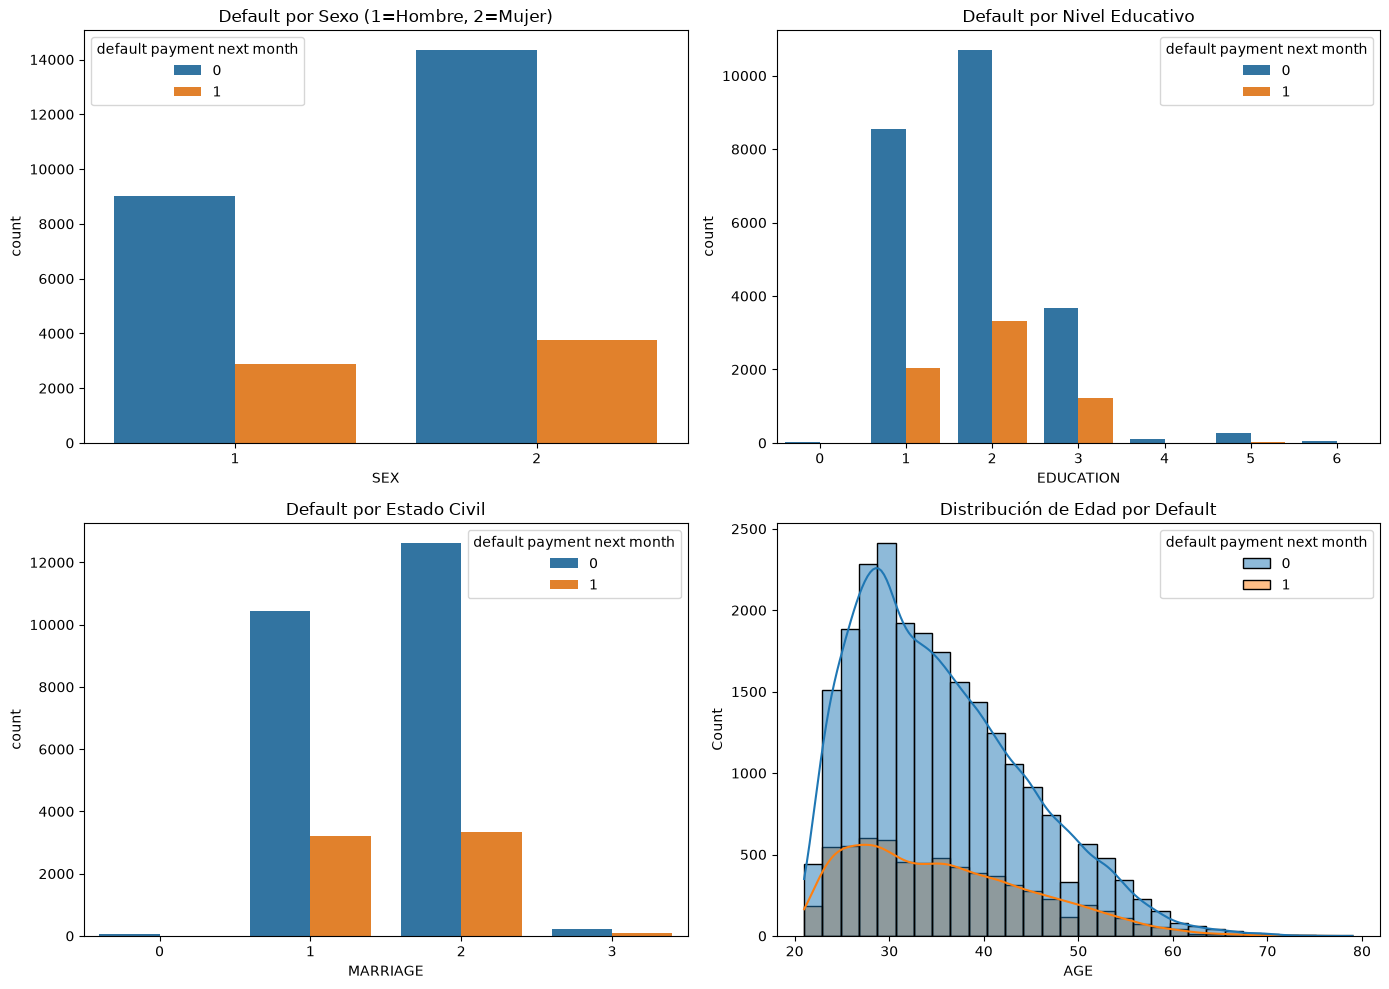

In [10]:
# 4.2 Análisis de variables demográficas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sexo (X2: 1=masculino, 2=femenino)[reference:6]
sns.countplot(data=df, x='SEX', hue=target_col, ax=axes[0,0])
axes[0,0].set_title('Default por Sexo (1=Hombre, 2=Mujer)')

# Educación (X3: 1=posgrado, 2=universidad, 3=secundaria, 4=otros)[reference:7]
sns.countplot(data=df, x='EDUCATION', hue=target_col, ax=axes[0,1])
axes[0,1].set_title('Default por Nivel Educativo')

# Estado civil (X4: 1=casado, 2=soltero, 3=otros)[reference:8]
sns.countplot(data=df, x='MARRIAGE', hue=target_col, ax=axes[1,0])
axes[1,0].set_title('Default por Estado Civil')

# Edad (X5)[reference:9]
sns.histplot(data=df, x='AGE', hue=target_col, kde=True, ax=axes[1,1], bins=30)
axes[1,1].set_title('Distribución de Edad por Default')

plt.tight_layout()
plt.savefig('eda_demograficas.png', dpi=150)
plt.show()

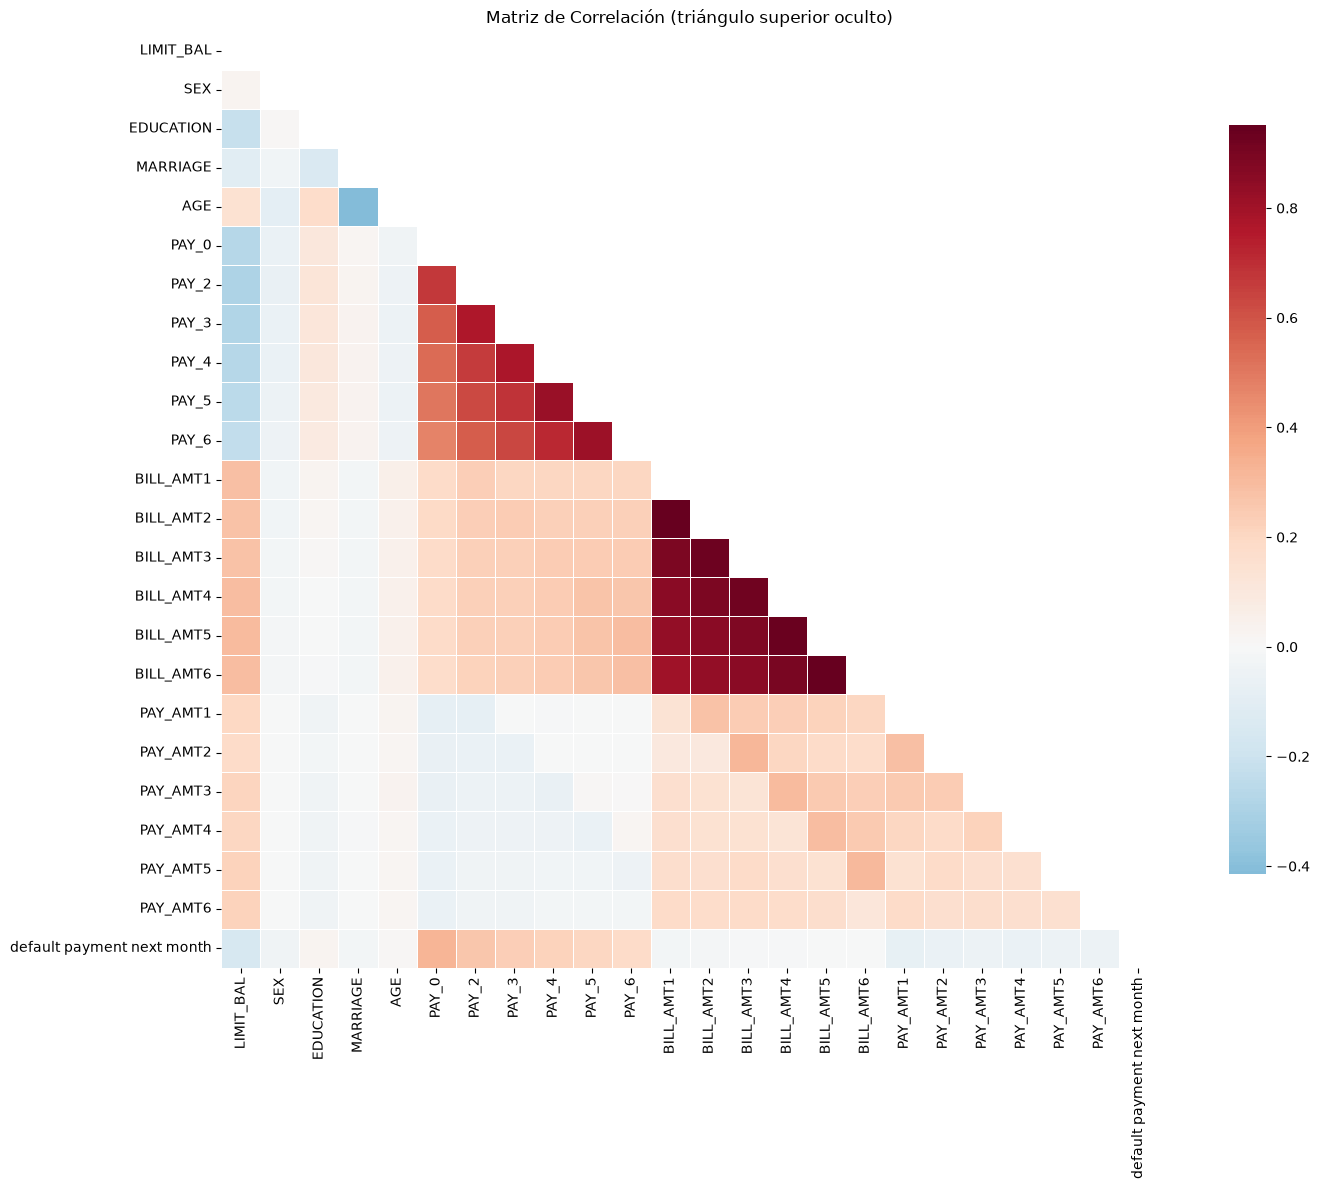

In [11]:
# 4.3 Matriz de correlación
plt.figure(figsize=(16, 12))

# Seleccionar columnas relevantes (excluyendo ID)
cols_to_plot = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
                'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                target_col]

corr_matrix = df[cols_to_plot].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, 
            annot=False, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación (triángulo superior oculto)')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150)
plt.show()

In [12]:
# -----------------------------------------------------------------------------
# 5. PREPROCESAMIENTO DE DATOS
# -----------------------------------------------------------------------------
print("PREPROCESAMIENTO DE DATOS")
# 5.1 Separar features (X) y target (y)
# La variable objetivo es la última columna
X = df.iloc[:, :-1].copy()  # Todas las columnas excepto la última
y = df.iloc[:, -1].copy()   # Última columna: 'default payment next month'

print(f"X shape: {X.shape}, y shape: {y.shape}")

PREPROCESAMIENTO DE DATOS
X shape: (30000, 24), y shape: (30000,)


In [13]:
# 5.2 Eliminar columna ID (no es predictiva)
if 'ID' in X.columns:
    X = X.drop('ID', axis=1)
    print("✅ Columna 'ID' eliminada")

✅ Columna 'ID' eliminada


In [14]:
# 5.3 Codificación de variables categóricas
# Las variables SEX, EDUCATION, MARRIAGE son categóricas ordinales
# EDUCATION: 0,1,2,3,4 (0=desconocido, 1=posgrado, 2=universidad, 3=secundaria, 4=otros)
# MARRIAGE: 0,1,2,3 (0=desconocido, 1=casado, 2=soltero, 3=otros)

# Mapeo para mejor interpretación
education_map = {0: 4, 1: 1, 2: 2, 3: 3, 4: 4}  # Normalizar: 0->4 (otros)
marriage_map = {0: 3, 1: 1, 2: 2, 3: 3}          # Normalizar: 0->3 (otros)

X['EDUCATION'] = X['EDUCATION'].map(education_map).fillna(4).astype(int)
X['MARRIAGE'] = X['MARRIAGE'].map(marriage_map).fillna(3).astype(int)

# Sex: 1=Hombre, 2=Mujer (no requiere cambio)
print("✅ Variables categóricas codificadas")

✅ Variables categóricas codificadas


In [15]:
# 5.4 División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 División de datos:")
print(f"   Train: {X_train.shape[0]} muestras")
print(f"   Test: {X_test.shape[0]} muestras")
print(f"   Proporción default en train: {y_train.mean():.2%}")
print(f"   Proporción default en test: {y_test.mean():.2%}")


📊 División de datos:
   Train: 21000 muestras
   Test: 9000 muestras
   Proporción default en train: 22.12%
   Proporción default en test: 22.12%


In [16]:
# 5.5 Escalado de características numéricas
# XGBoost y LightGBM son basados en árboles, no requieren escalado estricto,
# pero puede ayudar en la convergencia para ciertos parámetros.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✅ Datos escalados (StandardScaler)")

✅ Datos escalados (StandardScaler)


In [17]:
# 5.6 Cálculo de pesos para manejo de desbalanceo
# Proporción de clases para scale_pos_weight en XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"\n⚖️ scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")

# Para LightGBM: is_unbalance=True o class_weight


⚖️ scale_pos_weight (XGBoost): 3.52


In [18]:
# -----------------------------------------------------------------------------
# 6. ENTRENAMIENTO DE MODELOS
# -----------------------------------------------------------------------------

print("ENTRENAMIENTO DE MODELOS")

# 6.2 Modelo Base: LightGBM
print("\n" + "-"*40)
print("LightGBM - Modelo Base")
print("-"*40)

lgb_base = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',  # Manejo de desbalanceo
    random_state=42,
    verbose=-1
)

lgb_base.fit(X_train_scaled, y_train)
y_pred_lgb_base = lgb_base.predict(X_test_scaled)
y_prob_lgb_base = lgb_base.predict_proba(X_test_scaled)[:, 1]

print(f"✅ LightGBM base entrenado")

ENTRENAMIENTO DE MODELOS

----------------------------------------
LightGBM - Modelo Base
----------------------------------------
✅ LightGBM base entrenado


In [ ]:
# 6.1 Modelo Base: XGBoost
print("\n" + "-"*40)
print("XGBoost - Modelo Base")
print("-"*40)

xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)
xgb_base.fit(X_train_scaled, y_train)
y_pred_xgb_base = xgb_base.predict(X_test_scaled)
y_prob_xgb_base = xgb_base.predict_proba(X_test_scaled)[:, 1]

print("✅ XGBoost base entrenado")

In [19]:
# -----------------------------------------------------------------------------
# 7. OPTIMIZACIÓN DE HIPERPARÁMETROS
# -----------------------------------------------------------------------------
print("OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")

# 7.1 XGBoost - Grid Search
print("\n" + "-"*40)
print("XGBoost - Búsqueda de hiperparámetros")
print("-"*40)

xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid reducido para tiempo de ejecución razonable
xgb_param_grid_reduced = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
}

print("🔍 Realizando búsqueda de hiperparámetros (puede tomar varios minutos)...")

OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)

----------------------------------------
XGBoost - Búsqueda de hiperparámetros
----------------------------------------
🔍 Realizando búsqueda de hiperparámetros (puede tomar varios minutos)...


In [20]:
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        tree_method='hist',            # Método de histograma optimizado para GPU
        device='cuda',                 # Fuerza el uso de tu GPU NVIDIA
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid=xgb_param_grid_reduced,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)

print(f"\n✅ Mejores parámetros XGBoost: {xgb_grid.best_params_}")
print(f"   Mejor puntaje ROC-AUC (CV): {xgb_grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/rosariostijeras/Documentos/Universidad/04_semestre/Investigaciones Formativas/Base de datos e Machine learning/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:35:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/rosariostijeras/Documentos/Universidad/04_semestre/Investigaciones Formativas/Base de datos e Machine learning/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:35:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/rosariostijeras/Documentos/Universidad/04_semestre/Investigaciones Formativas/Base de datos e Machine learning/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:35:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.


✅ Mejores parámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
   Mejor puntaje ROC-AUC (CV): 0.7817


In [21]:
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)
y_prob_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]


# 7.2 LightGBM - Grid Search
print("\n" + "-"*40)
print("LightGBM - Búsqueda de hiperparámetros")
print("-"*40)

lgb_param_grid_reduced = {
    'n_estimators': [100, 150],
    'num_leaves': [31, 50],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
}

print("🔍 Realizando búsqueda de hiperparámetros (puede tomar varios minutos)...")


----------------------------------------
LightGBM - Búsqueda de hiperparámetros
----------------------------------------
🔍 Realizando búsqueda de hiperparámetros (puede tomar varios minutos)...


/home/rosariostijeras/Documentos/Universidad/04_semestre/Investigaciones Formativas/Base de datos e Machine learning/venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [19:35:32] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [22]:
lgb_grid = GridSearchCV(
    estimator=lgb.LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ),
    param_grid=lgb_param_grid_reduced,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

lgb_grid.fit(X_train_scaled, y_train)

print(f"\n✅ Mejores parámetros LightGBM: {lgb_grid.best_params_}")
print(f"   Mejor puntaje ROC-AUC (CV): {lgb_grid.best_score_:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Mejores parámetros LightGBM: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150, 'num_leaves': 31}
   Mejor puntaje ROC-AUC (CV): 0.7830


In [23]:
lgb_best = lgb_grid.best_estimator_
y_pred_lgb = lgb_best.predict(X_test_scaled)
y_prob_lgb = lgb_best.predict_proba(X_test_scaled)[:, 1]

In [24]:
# -----------------------------------------------------------------------------
# 8. EVALUACIÓN DE MODELOS
# -----------------------------------------------------------------------------

print("EVALUACIÓN DE MODELOS")

# 8.1 Función de evaluación
def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Calcula y retorna métricas de evaluación"""
    metrics = {
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precisión': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    return metrics

EVALUACIÓN DE MODELOS


In [26]:
# 8.2 Evaluar todos los modelos
models = [
    ('XGBoost Base', y_pred_xgb_base, y_prob_xgb_base),
    ('LightGBM Base', y_pred_lgb_base, y_prob_lgb_base),
    ('XGBoost Optimizado', y_pred_xgb, y_prob_xgb),
    ('LightGBM Optimizado', y_pred_lgb, y_prob_lgb),
]

results = []
for name, y_pred, y_prob in models:
    metrics = evaluate_model(y_test, y_pred, y_prob, name)
    results.append(metrics)

# 8.3 Tabla comparativa
df_results = pd.DataFrame(results)
print("\n📊 **COMPARATIVA DE MODELOS**")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

NameError: name 'y_pred_xgb_base' is not defined

In [ ]:
# 8.4 Matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, y_pred, _) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    axes[idx].set_title(f'Matriz de Confusión - {name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150)
plt.show()

In [ ]:
# 8.5 Curvas ROC
plt.figure(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#2980b9', '#27ae60']
linestyles = ['-', '-', '--', '--']

for idx, (name, _, y_prob) in enumerate(models):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colors[idx], linestyle=linestyles[idx],
             label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparativa de Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150)
plt.show()

In [ ]:
# 8.6 Reporte de clasificación detallado (mejor modelo)

print("REPORTE DE CLASIFICACIÓN - MEJOR MODELO")
# Identificar el mejor modelo por ROC-AUC
best_idx = np.argmax([r['ROC-AUC'] for r in results])
best_name = results[best_idx]['Modelo']
best_y_pred = [m[1] for m in models][best_idx]

print(f"\n🏆 Mejor modelo: {best_name}")
print(f"\n{classification_report(y_test, best_y_pred, target_names=['No Default', 'Default'])}")

In [ ]:
# -----------------------------------------------------------------------------
# 9. IMPORTANCIA DE CARACTERÍSTICAS
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("IMPORTANCIA DE CARACTERÍSTICAS")
print("="*60)

# 9.1 XGBoost - Importancia
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# XGBoost
importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(importance_xgb['feature'].tail(15), importance_xgb['importance'].tail(15))
axes[0].set_title('XGBoost - Top 15 Características más Importantes')
axes[0].set_xlabel('Importancia')

# LightGBM
importance_lgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_best.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(importance_lgb['feature'].tail(15), importance_lgb['importance'].tail(15))
axes[1].set_title('LightGBM - Top 15 Características más Importantes')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('importancia_features.png', dpi=150)
plt.show()

In [ ]:
print("\n🔍 **Top 5 características más importantes (XGBoost):**")
print(importance_xgb.tail(5).to_string(index=False))

print("\n🔍 **Top 5 características más importantes (LightGBM):**")
print(importance_lgb.tail(5).to_string(index=False))